Реализовать с помощью `Numpy` класс `MyMLP`, моделирующий работу полносвязной нейронной сети.

Реализуемый класс должен

1. Поддерживать создание любого числа слоев с любым числом нейронов. Тип инициализации весов не регламентируется.
2. Обеспечивать выбор следующих функции активации в рамках каждого слоя: `ReLU`, `sigmoid`, `linear`.
3. Поддерживать решение задачи классификации и регрессии (выбор соответствующего лосса, в том числе для задачи многоклассовой классификации).
4. В процессе обучения использовать самостоятельно реализованный механизм обратного распространения (вывод формул в формате markdown) для применения градиентного и стохастического градиентного спусков (с выбором размера батча)
5. Поддерживать использование `l1`, `l2` и `l1l2` регуляризаций.

Самостоятельно выбрать наборы данных (классификация и регрессия). Провести эксперименты (различные конфигурации сети: количество слоев, нейронов, функции активации, скорость обучения и тп. — минимум 5 различных конфигураций) и сравнить результаты работы (оценка качества модели + время обучения и инференса) реализованного класса `MyMLP` со следующими моделям (в одинаковых конфигурациях):

*   MLPClassifier/MLPRegressor из sklearn
*   TensorFlow
*   Keras
*   PyTorch

Результат представить в виде .ipynb блокнота, содержащего весь необходимый код и визуализации сравнения реализаций для рассмотренных конфигураций.


In [ ]:
import numpy as np
import pandas as pd
import time

from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.datasets import make_classification, make_regression, load_digits, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings

filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
# требует, чтобы у слоя были forward и backward
class Layer:
    def forward(self, input_data):
        raise NotImplementedError
    
    def backward(self, output_gradient, learning_rate):
        raise NotImplementedError


class Linear(Layer):
    def __init__(self, input_size, output_size, l1=0.0, l2=0.0):
        self.weights = np.random.randn(input_size, output_size) * np.sqrt(2.0 / (input_size + output_size))
        self.bias = np.zeros(output_size)
        self.dw = np.zeros_like(self.weights)
        self.l1 = l1
        self.l2 = l2
        
    def forward(self, input_data):
        # запоминаем вход для backward
        self.input = input_data

        return np.dot(self.input, self.weights) + self.bias
    
    def backward(self, output_gradient, learning_rate):
        # output_gradient — это dL/dY, пришедший от следующего слоя
        # градиент для весов dL/dW = X.T * dL/dY
        self.dw = np.dot(self.input.T, output_gradient)

        if self.l1 > 0:
            self.dw += self.l1 * np.sign(self.weights)
        if self.l2 > 0:
            self.dw += 2 * self.l2 * self.weights
        
        bias_gradient = np.sum(output_gradient, axis=0)
        
        # градиент для входа, чтобы отдать назад: dL/dX = dL/dY * W.T
        input_gradient = np.dot(output_gradient, self.weights.T)
        
        # градиентный спуск
        self.weights -= learning_rate * self.dw
        self.bias -= learning_rate * bias_gradient
        
        return input_gradient


class Sigmoid(Layer):
    def forward(self, input_data):
        self.input = input_data
        self.output = 1 / (1 + np.exp(-self.input))

        return self.output
    
    def backward(self, output_gradient, learning_rate):
        # производная сигмоиды = s * (1 - s)
        s = self.output
        derivative = s * (1 - s)

        return output_gradient * derivative


class Relu(Layer):
    def forward(self, input_data):
        self.input = input_data
        self.output = np.maximum(0, input_data)

        return self.output
    
    def backward(self, output_gradient, learning_rate):

        return output_gradient * (self.input > 0).astype(float)


class Softmax(Layer):
    def forward(self, input_data):
        # - максимум для численной стабильности 
        shifted_input = input_data - np.max(input_data, axis=1, keepdims=True)
        exp_values = np.exp(shifted_input)
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        return self.output
    
    def backward(self, output_gradient, learning_rate):
        input_gradient = np.empty_like(output_gradient)
        for i, (single_output, single_gradient) in enumerate(zip(self.output, output_gradient)):
            single_output = single_output.reshape(-1, 1)
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)
            input_gradient[i] = np.dot(jacobian_matrix, single_gradient)
        return input_gradient


class MSE:
    def loss(self, y_true, y_pred):
        return np.mean((y_pred - y_true) ** 2)
    
    def gradient(self, y_true, y_pred):
        return 2 * (y_pred - y_true) / y_true.size


class CrossEntropy:
    def loss(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
        # кросс-энтропия: сумма (y_true * log(y_pred))
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def gradient(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)

        return -(y_true / y_pred) / y_true.shape[0]


class MyMLP:

    def __init__(self, learning_rate, loss='mse'):
        self.learning_rate = learning_rate
        self.layers = []

        if loss == 'mse':
            self.loss_func = MSE()
        elif loss == 'crossentropy':
            self.loss_func = CrossEntropy()

    def add(self, layer):
        self.layers.append(layer)

    def forward(self, X):
        output = X
        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad, self.learning_rate)


    def fit(self, X, y, epochs=100, batch_size=32, verbose=True):
        history = []
        n_samples = X.shape[0]
        
        for epoch in range(epochs):
            # Перемешивание для SGD / Mini-batch
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_loss = 0
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # Forward
                pred = self.forward(X_batch)
                
                epoch_loss += self.loss_func.loss(y_batch, pred) * len(X_batch)
                
                # Backward
                grad = self.loss_func.gradient(y_batch, pred)
                self.backward(grad)
                
            epoch_loss /= n_samples
            history.append(epoch_loss)
            
            if verbose and (epoch+1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
                
        return history
    
    def predict(self, X):
        return self.forward(X)

In [ ]:
# data
def load_classification():
    data = load_digits()
    X = data.data
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    y_train_oh = keras.utils.to_categorical(y_train)
    y_test_oh = keras.utils.to_categorical(y_test)

    return X_train, X_test, y_train, y_test, y_train_oh, y_test_oh


def load_regression():
    data = load_diabetes()
    X = data.data
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train.reshape(-1,1), y_test.reshape(-1,1)


# MyMLP builder
def build_mymlp(input_dim, output_dim, cfg, task):
    model = MyMLP(cfg["lr"], loss='crossentropy' if task=="cls" else 'mse')

    prev = input_dim
    for h in cfg["layers"]:
        model.add(Linear(prev, h))
        model.add(Relu() if cfg["act"]=="relu" else Sigmoid())
        prev = h

    model.add(Linear(prev, output_dim))
    if task=="cls":
        model.add(Softmax())

    return model


# PyTorch
class TorchMLP(nn.Module):
    def __init__(self, input_dim, output_dim, cfg):
        super().__init__()
        layers_list = []
        prev = input_dim

        for h in cfg["layers"]:
            layers_list.append(nn.Linear(prev, h))
            layers_list.append(nn.ReLU() if cfg["act"]=="relu" else nn.Sigmoid())
            prev = h

        layers_list.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers_list)

    def forward(self, x):
        return self.net(x)


def plot_results(df, qual='accuracy'):
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    metrics = [qual, 'train_time', 'infer_time']
    titles = ['Качество', 'Время обучения (сек)', 'Время инференса (сек)']
    
    for i, metric in enumerate(metrics):
        sns.barplot(data=df, x='config_idx', y=metric, hue='model', ax=axes[i])
        axes[i].set_title(titles[i], fontsize=14)
        axes[i].set_xlabel("Номер конфигурации")
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
        if metric == 'accuracy':
            axes[i].set_ylim(0, 1.1)
            
    plt.tight_layout()
    plt.show()

In [ ]:
def run_benchmarks(configs, task='cls'):
    if task == 'cls':
        X_train, X_test, y_train, y_test, y_train_oh, y_test_oh = load_classification()
        input_dim = X_train.shape[1]
        output_dim = y_train_oh.shape[1]
    else:
        X_train, X_test, y_train, y_test = load_regression()
        input_dim = X_train.shape[1]
        output_dim = 1

    results = []
    batch_size = 32
    epochs = 30

    for idx, cfg in enumerate(configs):
        print(f"Тестирование конфига {idx}: {cfg}")
        
        frameworks = ['MyMLP', 'sklearn', 'PyTorch', 'Keras', 'TensorFlow']
        
        for fw in frameworks:
            t_train, t_inf, score = 0, 0, 0
            
            # MyMLP 
            if fw == 'MyMLP':
                model = build_mymlp(input_dim, output_dim, cfg, task)
                t0 = time.time()
                model.fit(X_train, y_train_oh if task=='cls' else y_train, 
                          epochs=epochs, batch_size=batch_size, verbose=False)
                t_train = time.time() - t0
                
                t0 = time.time()
                pred = model.predict(X_test)
                t_inf = time.time() - t0
                score = accuracy_score(y_test, np.argmax(pred, axis=1)) if task=='cls' else mean_squared_error(y_test, pred)

            # sklearn 
            elif fw == 'sklearn':
                if task == 'cls':
                    model = MLPClassifier(hidden_layer_sizes=cfg["layers"], 
                                          activation="relu" if cfg["act"]=="relu" else "logistic",
                                          learning_rate_init=cfg["lr"], max_iter=epochs, batch_size=batch_size, solver='sgd')
                else:
                    model = MLPRegressor(hidden_layer_sizes=cfg["layers"], 
                                         activation="relu" if cfg["act"]=="relu" else "logistic",
                                         learning_rate_init=cfg["lr"], max_iter=epochs, batch_size=batch_size, solver='sgd')
                t0 = time.time()
                model.fit(X_train, y_train.ravel())
                t_train = time.time() - t0
                t0 = time.time()
                pred = model.predict(X_test)
                t_inf = time.time() - t0
                score = accuracy_score(y_test, pred) if task=='cls' else mean_squared_error(y_test, pred)

            # PyTorch
            elif fw == 'PyTorch':
                model = TorchMLP(input_dim, output_dim, cfg)
                optimizer = torch.optim.SGD(model.parameters(), lr=cfg["lr"])
                criterion = nn.CrossEntropyLoss() if task=='cls' else nn.MSELoss()
                
                t0 = time.time()
                # Обучение батчами
                for _ in range(epochs):
                    for i in range(0, len(X_train), batch_size):
                        xb = torch.tensor(X_train[i:i+batch_size], dtype=torch.float32)
                        yb = torch.tensor(y_train[i:i+batch_size], dtype=torch.long if task=='cls' else torch.float32)
                        if task == 'cls': yb = yb.view(-1)
                        
                        optimizer.zero_grad()
                        loss = criterion(model(xb), yb)
                        loss.backward()
                        optimizer.step()
                t_train = time.time() - t0
                
                with torch.no_grad():
                    t0 = time.time()
                    out = model(torch.tensor(X_test, dtype=torch.float32))
                    t_inf = time.time() - t0
                    pred = out.argmax(dim=1).numpy() if task=='cls' else out.numpy()
                score = accuracy_score(y_test, pred) if task=='cls' else mean_squared_error(y_test, pred)

            # Keras/TF 
            elif fw in ['Keras', 'TensorFlow']:
                model = keras.Sequential([layers.Input(shape=(input_dim,))])
                for h in cfg["layers"]:
                    model.add(layers.Dense(h, activation=cfg["act"]))
                model.add(layers.Dense(output_dim, activation="softmax" if task=='cls' else None))
                
                model.compile(optimizer=keras.optimizers.SGD(cfg["lr"]), 
                              loss="categorical_crossentropy" if task=='cls' else "mse")
                
                t0 = time.time()
                model.fit(X_train, y_train_oh if task=='cls' else y_train, 
                          epochs=epochs, batch_size=batch_size, verbose=0)
                t_train = time.time() - t0
                
                t0 = time.time()
                pred = model.predict(X_test, verbose=0)
                t_inf = time.time() - t0
                score = accuracy_score(y_test, np.argmax(pred, axis=1)) if task=='cls' else mean_squared_error(y_test, pred)

            results.append({
                'config_idx': idx,
                'model': fw,
                'accuracy': score if task=='cls' else None,
                'rmse': np.sqrt(score) if task=='reg' else None,
                'train_time': t_train,
                'infer_time': t_inf
            })

    return pd.DataFrame(results)

Тестирование конфига 0: {'layers': [32], 'act': 'relu', 'lr': 0.01}
Тестирование конфига 1: {'layers': [64], 'act': 'sigmoid', 'lr': 0.01}
Тестирование конфига 2: {'layers': [64, 32], 'act': 'relu', 'lr': 0.01}
Тестирование конфига 3: {'layers': [128, 64], 'act': 'sigmoid', 'lr': 0.001}
Тестирование конфига 4: {'layers': [128, 128, 64], 'act': 'relu', 'lr': 0.001}


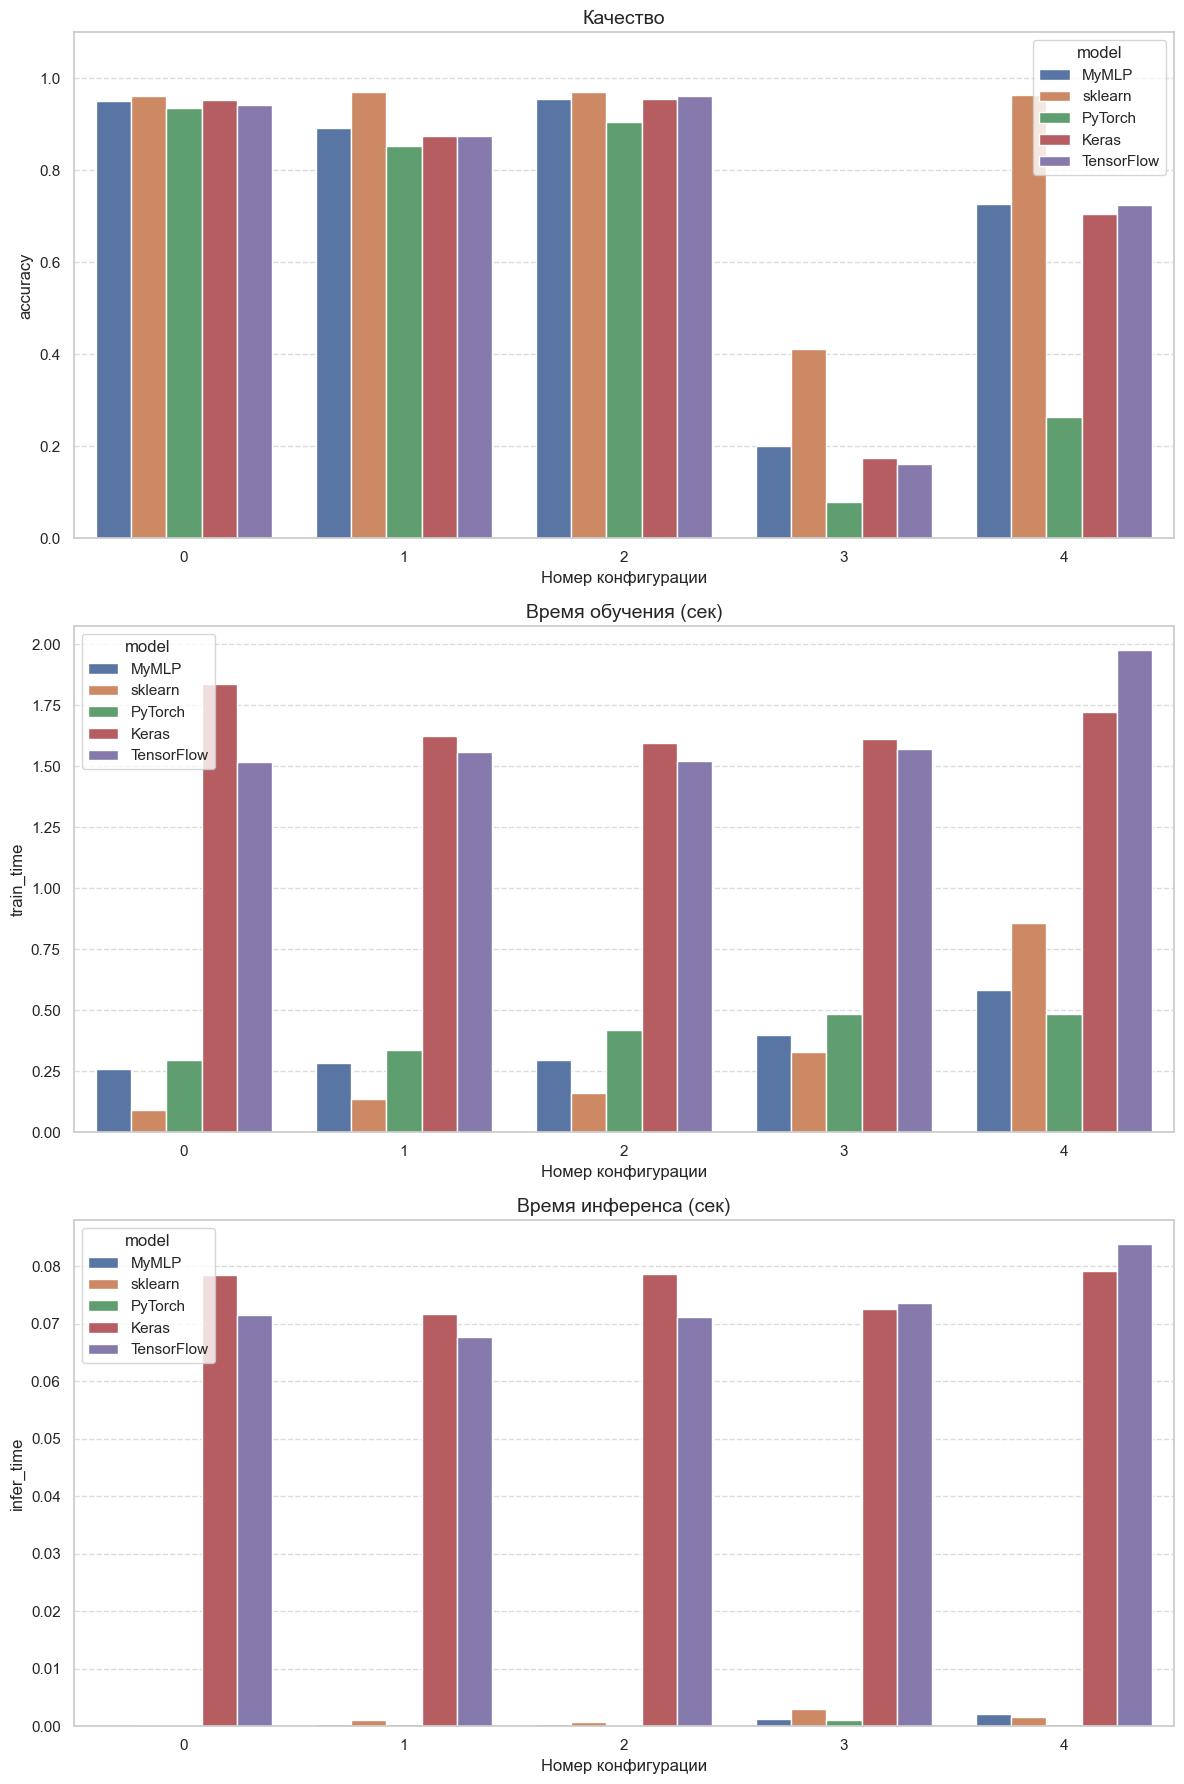

,config_idx,model,accuracy,rmse,train_time,infer_time
0,0,MyMLP,0.950000,None,0.261149,0.000075
1,0,sklearn,0.961111,None,0.089484,0.000288
2,0,PyTorch,0.936111,None,0.296543,0.000239
3,0,Keras,0.952778,None,1.837313,0.078405
4,0,TensorFlow,0.941667,None,1.515667,0.071443
5,1,MyMLP,0.891667,None,0.285544,0.000447
6,1,sklearn,0.969444,None,0.134259,0.001154
7,1,PyTorch,0.852778,None,0.335713,0.000470
8,1,Keras,0.875000,None,1.625020,0.071653
9,1,TensorFlow,0.875000,None,1.559047,0.067722


In [5]:
# configurations
configs = [
    {"layers":[32], "act":"relu", "lr":0.01},
    {"layers":[64], "act":"sigmoid", "lr":0.01},
    {"layers":[64,32], "act":"relu", "lr":0.01},
    {"layers":[128,64], "act":"sigmoid", "lr":0.001},
    {"layers":[128,128,64], "act":"relu", "lr":0.001},
]

df = run_benchmarks(configs=configs)

plot_results(df)

df

Тестирование конфига 0: {'layers': [32], 'act': 'relu', 'lr': 0.0001}
Тестирование конфига 1: {'layers': [64], 'act': 'sigmoid', 'lr': 0.0001}
Тестирование конфига 2: {'layers': [64, 32], 'act': 'relu', 'lr': 0.0001}


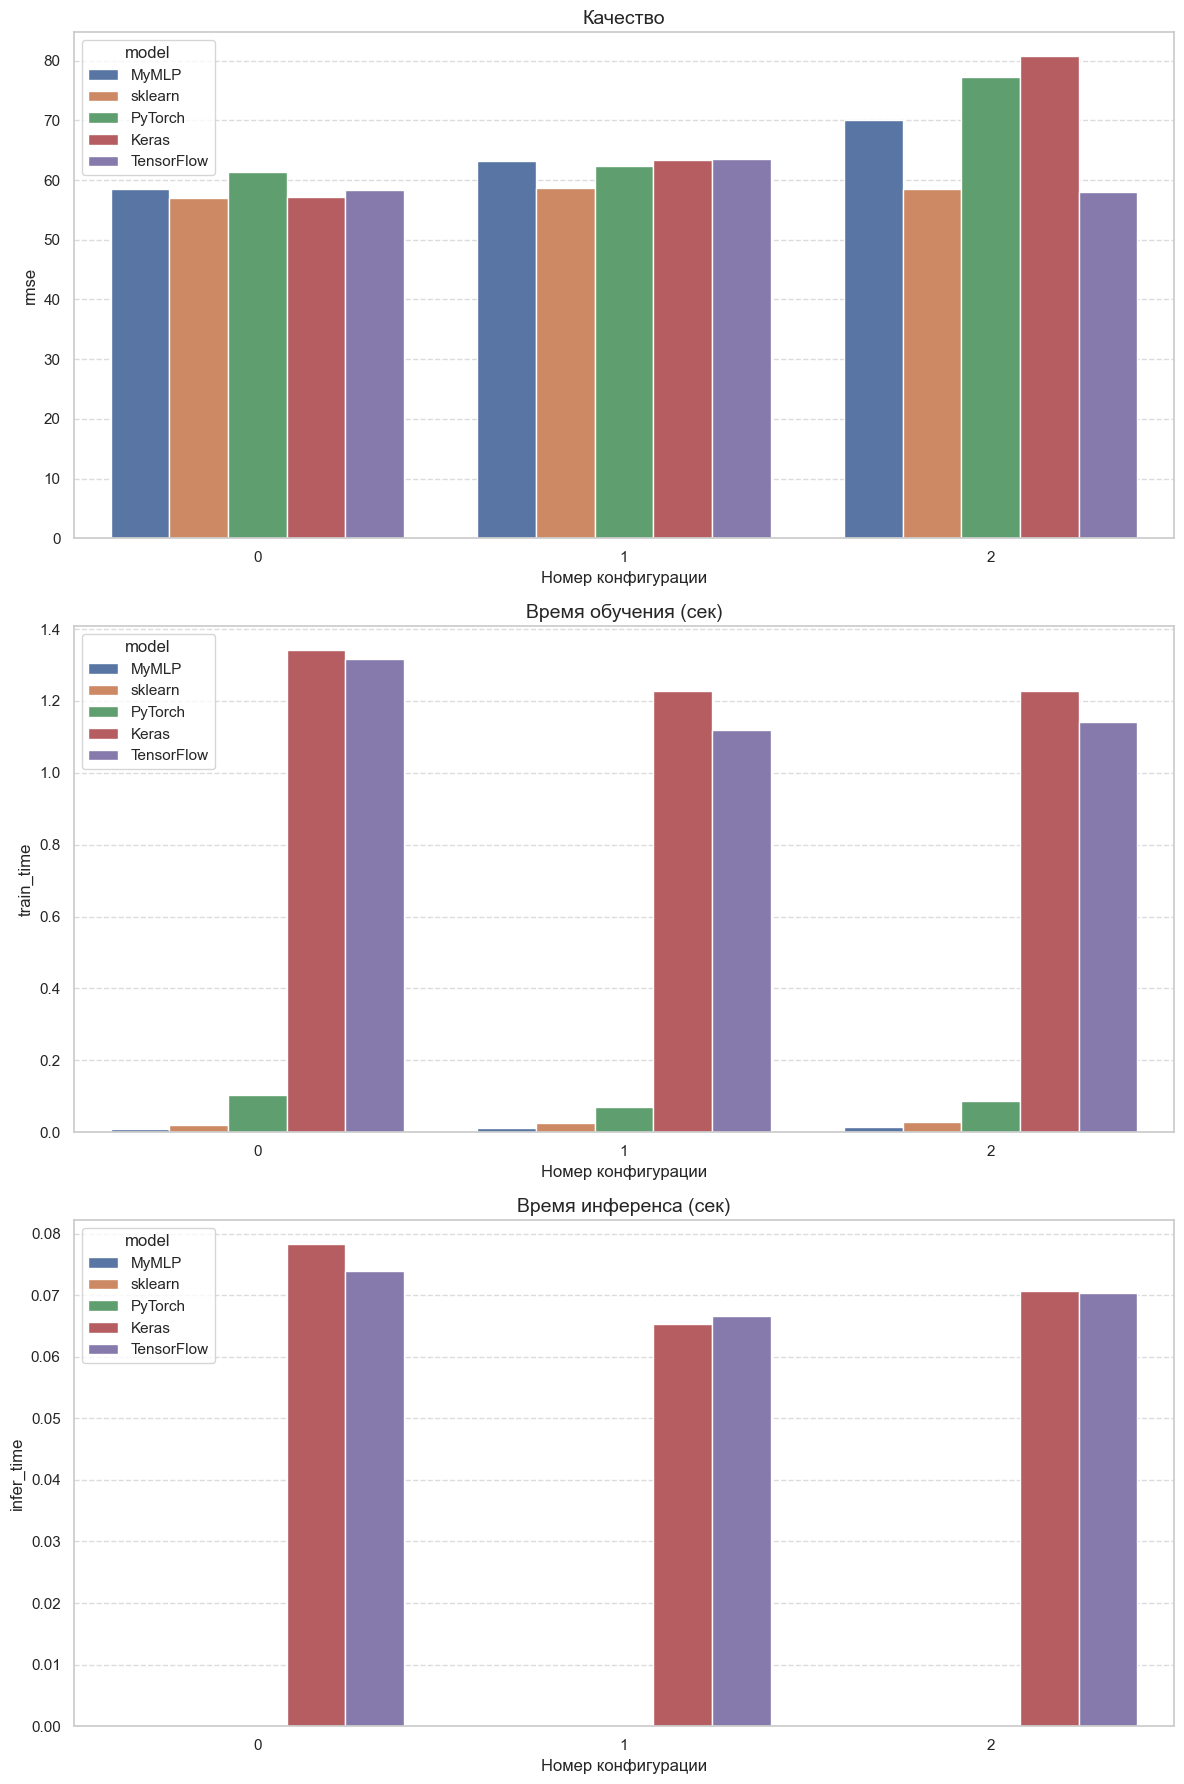

,config_idx,model,accuracy,rmse,train_time,infer_time
0,0,MyMLP,None,58.475966,0.009157,0.000017
1,0,sklearn,None,56.924527,0.020729,0.000197
2,0,PyTorch,None,61.346421,0.104509,0.000065
3,0,Keras,None,57.231703,1.340453,0.078236
4,0,TensorFlow,None,58.288948,1.315910,0.073939
5,1,MyMLP,None,63.249249,0.011603,0.000045
6,1,sklearn,None,58.743188,0.026927,0.000200
7,1,PyTorch,None,62.439398,0.068869,0.000048
8,1,Keras,None,63.350167,1.226313,0.065314
9,1,TensorFlow,None,63.541430,1.120114,0.066683


In [6]:
configs = [
    {"layers":[32], "act":"relu", "lr":0.0001},
    {"layers":[64], "act":"sigmoid", "lr":0.0001},
    {"layers":[64,32], "act":"relu", "lr":0.0001},
]


df_r = run_benchmarks(configs=configs, task='reg')

plot_results(df_r, qual='rmse')

df_r